# Agriculture Price Prediction (Regression)
Uses a public crop price dataset to train an ANN regression model. Evaluated with MSE and R² Score.

In [1]:
!pip install tensorflow scikit-learn pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

# Load dataset from GitHub (crop price dataset)
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/crop_production.csv'
try:
    df = pd.read_csv(url)
    print('Dataset loaded from GitHub.')
    print(df.head())
except:
    print('Could not load from URL. Generating synthetic crop data instead.')
    np.random.seed(42)
    n = 2000
    df = pd.DataFrame({
        'Area': np.random.uniform(1, 100, n),
        'Annual_Rainfall': np.random.uniform(100, 3000, n),
        'Fertilizer': np.random.uniform(50, 500, n),
        'Pesticide': np.random.uniform(10, 200, n),
        'Production': np.random.uniform(50, 5000, n),
    })
    df['Price'] = 1000 + 5*df['Production'] - 2*df['Area'] + 0.3*df['Annual_Rainfall'] + np.random.normal(0, 200, n)
    print(df.head())

Could not load from URL. Generating synthetic crop data instead.
        Area  Annual_Rainfall  Fertilizer   Pesticide   Production  \
0  38.079472       858.946483  307.398145  133.168821  3615.326224   
1  95.120716       816.238517  412.444548   42.753409  3452.050872   
2  73.467400      2728.138284  392.072418  175.754967   523.983283   
3  60.267190       823.683980  119.254957  126.492085  4616.733404   
4  16.445845       888.654206  117.162261   39.868738  2863.937401   

          Price  
0  18960.583778  
1  18089.847261  
2   4369.186884  
3  23975.463170  
4  15775.918435  


In [3]:
# Preprocessing: select numeric columns, drop NaN
df_num = df.select_dtypes(include=[np.number]).dropna()

# Use last column as target if 'Price' not found
target_col = 'Price' if 'Price' in df_num.columns else df_num.columns[-1]
feature_cols = [c for c in df_num.columns if c != target_col]

X = df_num[feature_cols].values
y = df_num[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc = scaler_y.transform(y_test)

print(f'Features: {feature_cols}, Target: {target_col}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Features: ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Production'], Target: Price
Train: (1600, 5), Test: (400, 5)


In [4]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
], name='Crop_Price_ANN')

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

C:\Users\chhav\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Crop_Price_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train, y_train_sc,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.4065 - mae: 0.4921 - val_loss: 0.0523 - val_mae: 0.1790
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0759 - mae: 0.2168 - val_loss: 0.0106 - val_mae: 0.0839
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0551 - mae: 0.1822 - val_loss: 0.0094 - val_mae: 0.0747
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0458 - mae: 0.1681 - val_loss: 0.0068 - val_mae: 0.0652
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0391 - mae: 0.1541 - val_loss: 0.0104 - val_mae: 0.0799
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0362 - mae: 0.1475 - val_loss: 0.0068 - val_mae: 0.0665
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0301 - mae: 0.1355 - val_loss: 0.0067 - val_mae: 0.0660
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0295 - mae: 0.1337 - val_loss: 0.0103 - val_mae: 0.0770
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.02

In [6]:
y_pred_sc = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_sc)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE : {mse:.4f}')
print(f'RMSE: {np.sqrt(mse):.4f}')
print(f'R²  : {r2:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MSE : 1731722.8775
RMSE: 1315.9494
R²  : 0.9646


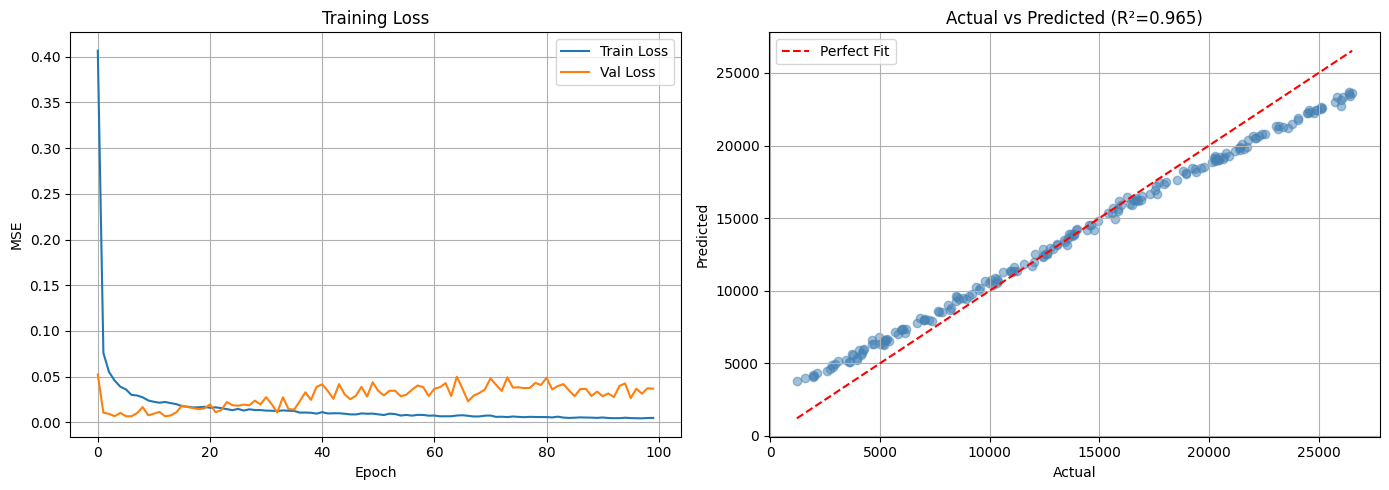

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(y_test[:200], y_pred[:200], alpha=0.5, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[1].plot([mn, mx], [mn, mx], 'r--', label='Perfect Fit')
axes[1].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
plt.savefig("plot.png")

<Figure size 640x480 with 0 Axes>